In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
ethiopia = pd.read_csv("ethiopia.csv")
kenya = pd.read_csv("kenya.csv")
sudan = pd.read_csv("sudan.csv")
tanzania = pd.read_csv("tanzania.csv")
nigeria = pd.read_csv("nigeria.csv")

# add country names
ethiopia["Country"] = "Ethiopia"
kenya["Country"] = "Kenya"
sudan["Country"] = "Sudan"
tanzania["Country"] = "Tanzania"
nigeria["Country"] = "Nigeria"

# combine
df = pd.concat([ethiopia, kenya, sudan, tanzania, nigeria])

df.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country
0,2015,1,11.73,22.75,3.44,19.31,0.0,41.79,2.73,5.07,77.13,4.00,Ethiopia
1,2015,2,12.30,24.01,4.09,19.92,0.0,33.29,2.39,4.19,77.14,3.35,Ethiopia
2,2015,3,12.49,24.17,3.97,20.20,0.0,33.83,1.77,2.76,77.11,3.43,Ethiopia
3,2015,4,14.08,23.78,6.90,16.88,0.0,38.84,0.87,1.28,77.07,4.60,Ethiopia
4,2015,5,14.06,23.15,7.32,15.83,0.0,47.07,1.34,2.14,77.01,5.58,Ethiopia


In [7]:
df["Date"] = pd.to_datetime(df["YEAR"] * 1000 + df["DOY"], format="%Y%j")
df["Month"] = df["Date"].dt.month
df["Year"] = df["Date"].dt.year

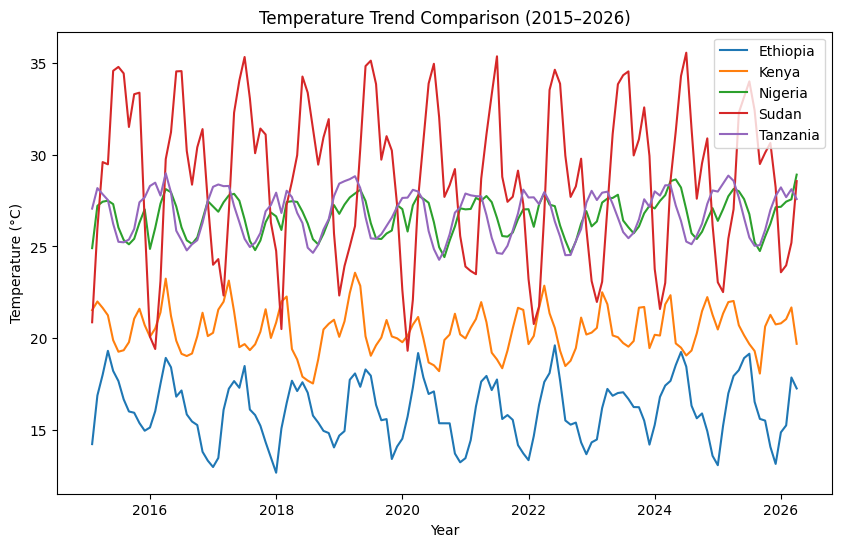

In [8]:
monthly_temp = df.groupby(["Country", "Year", "Month"])["T2M"].mean().reset_index()

plt.figure(figsize=(10,6))

for country in monthly_temp["Country"].unique():
    data = monthly_temp[monthly_temp["Country"] == country]
    plt.plot(data["Year"] + data["Month"]/12, data["T2M"], label=country)

plt.title("Temperature Trend Comparison (2015–2026)")
plt.xlabel("Year")
plt.ylabel("Temperature (°C)")
plt.legend()
plt.show()

In [9]:
temp_summary = df.groupby("Country")["T2M"].agg(["mean", "median", "std"])
temp_summary

,mean,median,std
Country,,,
Ethiopia,16.068500,16.04,1.898050
Kenya,20.427600,20.36,1.440824
Nigeria,26.656928,26.82,1.123335
Sudan,28.759007,29.16,4.681305
Tanzania,26.802422,26.99,1.325388


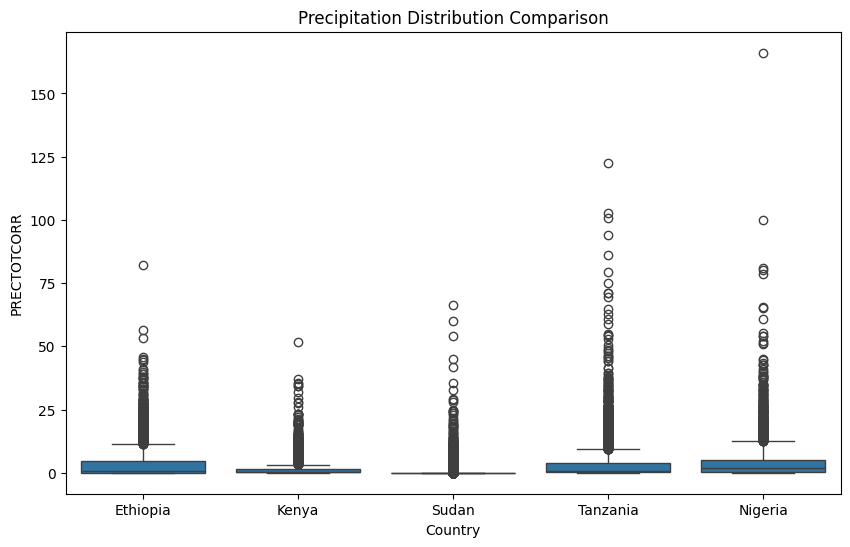

In [10]:
plt.figure(figsize=(10,6))
sns.boxplot(x="Country", y="PRECTOTCORR", data=df)
plt.title("Precipitation Distribution Comparison")
plt.show()

In [11]:
precip_summary = df.groupby("Country")["PRECTOTCORR"].agg(["mean", "median", "std"])
precip_summary

,mean,median,std
Country,,,
Ethiopia,3.633795,0.82,6.289061
Kenya,1.468162,0.38,3.180228
Nigeria,4.213914,1.84,7.266742
Sudan,0.643875,0.00,3.057672
Tanzania,3.740256,0.64,8.003947


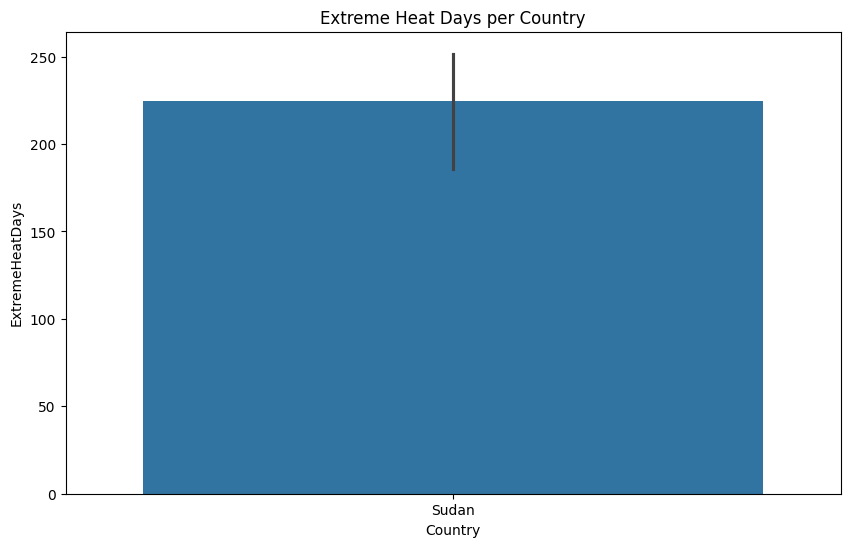

In [12]:
extreme_heat = df[df["T2M_MAX"] > 35]

heat_count = extreme_heat.groupby(["Country", "Year"]).size().reset_index(name="ExtremeHeatDays")

plt.figure(figsize=(10,6))
sns.barplot(x="Country", y="ExtremeHeatDays", data=heat_count)
plt.title("Extreme Heat Days per Country")
plt.show()

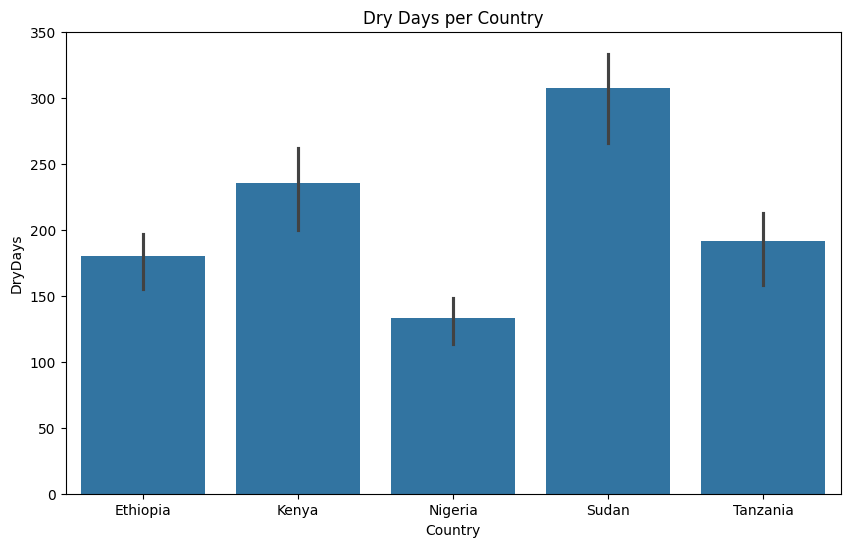

In [13]:
dry_days = df[df["PRECTOTCORR"] < 1]

dry_count = dry_days.groupby(["Country", "Year"]).size().reset_index(name="DryDays")

plt.figure(figsize=(10,6))
sns.barplot(x="Country", y="DryDays", data=dry_count)
plt.title("Dry Days per Country")
plt.show()

In [14]:
from scipy.stats import f_oneway

groups = [df[df["Country"] == c]["T2M"] for c in df["Country"].unique()]

f_stat, p_value = f_oneway(*groups)

print("F-statistic:", f_stat)
print("P-value:", p_value)

F-statistic: 18938.745697069884
P-value: 0.0


In [15]:
ranking = pd.DataFrame({
    "Country": temp_summary.index,
    "AvgTemp": temp_summary["mean"],
    "RainfallVar": precip_summary["std"]
})

ranking = ranking.sort_values(by=["AvgTemp", "RainfallVar"], ascending=False)

ranking

,Country,AvgTemp,RainfallVar
Country,,,
Sudan,Sudan,28.759007,3.057672
Tanzania,Tanzania,26.802422,8.003947
Nigeria,Nigeria,26.656928,7.266742
Kenya,Kenya,20.427600,3.180228
Ethiopia,Ethiopia,16.068500,6.289061


### Key Insights for COP32

- Sudan shows the highest temperatures, indicating strong warming trends and increasing climate stress.
- Nigeria and Tanzania show high variability in rainfall, suggesting unstable precipitation patterns.
- Extreme heat days are most frequent in Sudan and Nigeria, highlighting vulnerability to heatwaves.
- Ethiopia shows moderate temperature but increasing variability, making it vulnerable to both drought and rainfall instability.
- Based on the data, Sudan should be prioritized for climate finance due to extreme heat exposure and environmental stress.